# Tests for Wiener-SVD Unfolding Tool

- **Closure test** (Asimov): loops over all `var_configs`; MC reco as fake data; covariance = MC stat only
- **Fake data tests**: loops over all `var_configs` × `FAKE_DATA_TEST_SPECS`; covariance = MC stat + GENIE xsec
- **Outputs**: figures per test + `fake_data_chi2_summary.csv` / `closure_chi2_summary.csv` and pivot tables

**MC sample**: GENIE CCQE `merged_perTPC` (`dataset_locations.GENIE_GROUP_GLOBS`).


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from os import path, makedirs
from datetime import datetime
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import save_fig_base_dir
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE, GENIE_GROUP_GLOBS
from analysis_village.numucc_1p0pi.syst_disk_layout import category_summary_npz_path
from analysis_village.numucc_1p0pi.syst_category_summary import (
    category_cov_frac,
    load_category_syst_summary,
    CAT_MCSTAT,
    CAT_GENIE_XSEC,
)
from analysis_village.unfolding.wienersvd import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt
from IPython.display import display

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)
plt.style.use("presentation.mplstyle")


In [3]:
save_result = True
save_fig = save_result

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"unfolding-fake_data_tests-{today_str}")
if save_fig and not path.exists(save_fig_dir):
    makedirs(save_fig_dir)
print("saving plots in", save_fig_dir)

DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"
DIR_GENIE_CCQE = path.dirname(GENIE_GROUP_GLOBS["CCQE"])
KEYS2LOAD_MC = ["hdr", "evt", "mcnu"]
N_MAX_CONCAT = 999

SYST_DISK_ROOT = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final"
CATEGORY_SUMMARY_OUT = (
    Path(PLOTS_BASE) / "syst_uncertainty_breakdown" / "final_selected" / "category_syst_summary.npz"
)
CATEGORY_SUMMARY_NPZ = category_summary_npz_path(SYST_DISK_ROOT)
if not path.isfile(CATEGORY_SUMMARY_NPZ) and CATEGORY_SUMMARY_OUT.is_file():
    CATEGORY_SUMMARY_NPZ = str(CATEGORY_SUMMARY_OUT)

print("GENIE CCQE dir:", DIR_GENIE_CCQE)
print("category summary:", CATEGORY_SUMMARY_NPZ, "exists =", path.isfile(CATEGORY_SUMMARY_NPZ))


saving plots in /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding-fake_data_tests-20260526
GENIE CCQE dir: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC
category summary: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/CategorySummary/category_syst_summary.npz exists = True


## Load GENIE CCQE MC


In [4]:
genie_dfs = dfs_from_dir(
    DIR_GENIE_CCQE,
    filename_str="sel_mup-wgts_genie_CCQE",
    keys2load=KEYS2LOAD_MC,
    n_max_concat=N_MAX_CONCAT,
)
mc_evt_df = genie_dfs["evt"]
mc_hdr_df = genie_dfs["hdr"]
mc_nu_df = genie_dfs["mcnu"]
print(f"GENIE CCQE: evt={len(mc_evt_df):,}  hdr={len(mc_hdr_df):,}  mcnu={len(mc_nu_df):,}")

Found 19 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0002.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0003.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0004.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05_11_024530__sel_mup-wgts_genie_CCQE_merged_0005.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC/2026_05

100%|██████████| 19/19 [01:53<00:00,  5.96s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
GENIE CCQE: evt=70,535  hdr=6,061,666  mcnu=10,933,450


In [ ]:
mc_nu_df.mc.nmu

__ntuple  entry  rec.mc.nu..index
2         0      0                   0
                 1                   1
                 2                   0
          1      0                   0
          2      0                   0
                                    ..
355356    9      2                   0
          10     0                   0
          11     0                   0
          12     0                   1
                 1                   0
Name: npi, Length: 10933450, dtype: int64

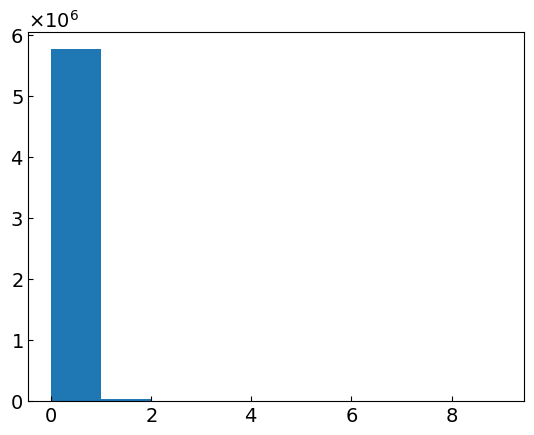

0.7409599143570834


In [13]:
isccqe = (mc_nu_df.mc.genie_mode == 0)
var = mc_nu_df[isccqe].mc.npi
plt.hist(var, bins=np.arange(0, 10, 1))
plt.show();
print(len(mc_nu_df[isccqe & (mc_nu_df.mc.npi == 0) & (mc_nu_df.mc.npi0 == 0)]) / len(mc_nu_df[(mc_nu_df.mc.npi == 0) & (mc_nu_df.mc.npi0 == 0)]))

In [12]:
mc_nu_df.mc.npi0

__ntuple  entry  rec.mc.nu..index
2         0      0                   0
                 1                   0
                 2                   0
          1      0                   0
          2      0                   0
                                    ..
355356    9      2                   0
          10     0                   0
          11     0                   0
          12     0                   0
                 1                   0
Name: npi0, Length: 10933450, dtype: int64

In [ ]:
# mc_nu_df.columns = pd.MultiIndex.from_tuples(
#     [tuple(["mc"] + list(c)) for c in mc_nu_df.columns]
# )
mc_tot_pot = mc_hdr_df["pot"].sum()
pot_str = get_pot_str(mc_tot_pot)
mc_evt_df["pot_weight"] = np.ones(len(mc_evt_df))
mc_nu_df["pot_weight"] = np.ones(len(mc_nu_df))

# mc_evt_df.loc[:, "topo_categ"] = get_topo_category(mc_evt_df)
# mc_evt_df.loc[:, "genie_categ"] = get_genie_category(mc_evt_df)
# mc_nu_df.loc[:, "topo_categ"] = get_topo_category(mc_nu_df)
# mc_nu_df.loc[:, "genie_categ"] = get_genie_category(mc_nu_df)
# mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999

# from pyanalib.variable_calculator import *
# tki_var_names = ["del_alpha", "del_phi", "del_Tp", "del_p", "del_Tp_x", "del_Tp_y"]
# slc_mudf = mc_evt_df.mu.pfp.trk.truth.p
# slc_pdf = mc_evt_df.p.pfp.trk.truth.p
# slc_P_mu_col = pad_column_name(("totp",), slc_mudf)
# slc_P_p_col = pad_column_name(("totp",), slc_pdf)
# tki_reco = get_cc1p0pi_tki(slc_mudf, slc_pdf, slc_P_mu_col, slc_P_p_col)
# for var_name in tki_var_names:
#     mc_evt_df = multicol_add(mc_evt_df, tki_reco[var_name].rename("mc_" + var_name))
# mc_mudf = mc_nu_df.mc.mu
# mc_pdf = mc_nu_df.mc.p
# mc_P_mu_col = pad_column_name(("totp",), mc_mudf)
# mc_P_p_col = pad_column_name(("totp",), mc_pdf)
# tki_mc = get_cc1p0pi_tki(mc_mudf, mc_pdf, mc_P_mu_col, mc_P_p_col)
# for var_name in tki_var_names:
#     mc_nu_df = multicol_add(mc_nu_df, tki_mc[var_name].rename(var_name))

# perTPC_inset = 5
# def perTPC_cut(df):
#     in_TPC1_cut = (
#         InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset)
#         & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
#         & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
#     )
#     in_TPC2_cut = (
#         InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset)
#         & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
#         & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
#     )
#     return in_TPC1_cut | in_TPC2_cut

# mc_evt_df = mc_evt_df[perTPC_cut(mc_evt_df)]

In [ ]:
# Measurement variables (used for closure + fake-data loops)
var_configs = [
    # VariableConfig.all_events(),
    VariableConfig.muon_momentum(),
    VariableConfig.muon_direction(),
    VariableConfig.proton_momentum(),
    VariableConfig.proton_direction(),
    VariableConfig.tki_del_Tp(),
    VariableConfig.tki_del_Tp_x(),
    VariableConfig.tki_del_Tp_y(),
    VariableConfig.tki_del_p(),
    VariableConfig.tki_del_alpha(),
    VariableConfig.tki_del_phi(),
]

# Fake-data injection: (test_name, plot_label, kwargs for FakeDataWeights.get_weights).
# Bump: ``test_name`` must start with ``bump_``. ``bump_area_bin_fraction`` fixes the
# total weighted excess to that fraction of the nominal weighted count in the center bin.
FAKE_DATA_TEST_SPECS = [
    ("mec_test", "MEC Scale", {"scale_factor": 0.5}),
    ("qe_test", "QE Scale", {"scale_factor": 1.2}),
    ("q2_test_alpha_0.3", r"$Q^2$ tilt", {"scale_factor": 0.3}),
    ("costh_weight_scale_0.7", "Forward Muon Scale", {"scale_factor": 0.7}),
    ("proton_P_tilt_alpha_0.3", "Proton Momentum Tilt", {"scale_factor": 0.3}),
    (
        "bump_area0p5_center_bin",
        None,
        {"bump_area_bin_fraction": 0.5},
    ),
    (
        "bump_area1_center_bin",
        None,
        {"bump_area_bin_fraction": 1.0},
    ),
    (
        "bump_area1p5_center_bin",
        None,
        {"bump_area_bin_fraction": 1.5},
    ),
]

print(f"{len(var_configs)} variables × {len(FAKE_DATA_TEST_SPECS)} fake-data tests")


In [ ]:
_CAT_SYST_LABELS = {
    "flux": "Flux",
    "g4": "G4",
    "mcstat": "MC stat.",
    "detector": "Detector",
    "cosmics": "Cosmics",
    "genie_rate": "GENIE (rate)",
    "genie_xsec": "GENIE (xsec)",
    "pot": "POT",
    "ntargets": "Ntargets",
}


def get_syst_unc(var_config, plot=False, save_fig=False, components=None):
    """Fractional diagonal uncertainty from category summary (optional per-category plot)."""
    from analysis_village.numucc_1p0pi.syst_category_summary import load_category_syst_summary

    summary = load_category_syst_summary(CATEGORY_SUMMARY_NPZ)
    vsn = var_config.var_save_name
    if components is None:
        _, cov = get_category_summary_syst_unc(
            var_config,
            syst_kind="xsec",
            syst_disk_root=SYST_DISK_ROOT,
            category_syst_summary_path=CATEGORY_SUMMARY_NPZ,
        )
        unc = np.sqrt(np.diag(cov))
    else:
        mats = []
        for key in components:
            c = category_cov_frac(summary, vsn, key)
            if c is not None:
                mats.append(c)
        cov = sum(mats)
        unc = np.sqrt(np.diag(cov))

    if plot:
        pack = summary["by_var"][vsn]
        keys = components if components is not None else list(pack["categories"].keys())
        for cat_key in keys:
            if cat_key not in pack["categories"]:
                continue
            w = np.asarray(pack["categories"][cat_key]["frac_unc_pct"], dtype=float) / 100.0
            plt.hist(
                var_config.bin_centers,
                bins=var_config.bins,
                weights=w,
                histtype="step",
                linewidth=2,
                label=_CAT_SYST_LABELS.get(cat_key, cat_key),
            )
        plt.hist(
            var_config.bin_centers,
            bins=var_config.bins,
            weights=unc,
            histtype="step",
            linewidth=2,
            color="k",
            label="Total",
        )
        plt.xlim(var_config.bins[0], var_config.bins[-1])
        plt.ylim(0, max(unc) * 1.4)
        plt.xlabel(var_config.var_labels[1])
        plt.ylabel("Fractional uncertainty")
        plt.legend(fontsize=11, ncol=3, loc="upper center")
        plt.grid(which="major", linestyle="-", linewidth=0.7, alpha=0.7)
        plt.minorticks_on()
        if save_fig:
            plt.savefig(
                f"{save_fig_dir}/uncertainty_breakdown-{vsn}.pdf",
                bbox_inches="tight",
            )
        plt.show()
    return unc, cov


## Event rate → cross section conversion

Configure flux file, fiducial volume, and POT below. **V_SBND** matches the ray-traced **FV_split_truncY** geometry used for `Gen1.root` (see `analysis_village/flux/gsimple_raytrace.ipynb`): two anode slabs with **10 cm cathode inset** ($10<|x|<190$ cm) and **z-dependent** $|y|$ limits.


In [ ]:
# --- rate → cross section conversion (configure here) ---
from analysis_village.flux.raytrace_volume_defs import (
    FV_SPLIT_TRUNCY_BOXES,
    RAYTRACE_VOLUME_LABEL,
)

FLUX_FILE = "/exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace/Gen1.root"
FLUX_FV = "FV_split_truncY"  # geometry for Gen1.root (gsimple_raytrace.ipynb)
CATHODE_INSET_CM = 10  # exclude |x| < 10 cm at cathode gap
XSEC_TOT_POT = mc_tot_pot  # MC POT for fake-data / closure tests

# V_SBND: union of anode slabs (10 < |x| < 190), z-dependent |y|, 10 < z < 450 cm
print(f"Fiducial volume ({FLUX_FV}): {RAYTRACE_VOLUME_LABEL[FLUX_FV]}")
print(f"Cathode inset: {CATHODE_INSET_CM} cm")
V_SBND = 0.0
for i, box in enumerate(FV_SPLIT_TRUNCY_BOXES):
    dx = box["x_range"][1] - box["x_range"][0]
    dy = box["y_range"][1] - box["y_range"][0]
    dz = box["z_range"][1] - box["z_range"][0]
    v_box = dx * dy * dz
    V_SBND += v_box
    print(
        f"  slab {i + 1}: x={box['x_range']} cm, y={box['y_range']} cm, z={box['z_range']} cm"
        f" -> {v_box:.4e} cm³"
    )
print(f"V_SBND = {V_SBND:.6e} cm³")

# Plot νμ flux and print ∫Φ dE per cm² per POT
integrated_flux_per_pot = get_integrated_flux(FLUX_FILE, plot=True)
integrated_flux = integrated_flux_per_pot * XSEC_TOT_POT
print(f"Integrated flux × POT = {integrated_flux:.6e} ν/cm²")

N_TARGETS = (RHO * V_SBND / M_AR) * N_A
print(f"# argon target nuclei: {N_TARGETS:.4e}")

XSEC_UNIT = 1.0 / (integrated_flux * N_TARGETS)
print(f"XSEC_UNIT = {XSEC_UNIT:.6e} cm²/nucleon")


In [ ]:
# --- Wiener-SVD / plotting defaults ---
C_type = 2
Norm_type = 0
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

summary = load_category_syst_summary(CATEGORY_SUMMARY_NPZ)


def _covariance_per_bin_width(cov, bin_widths):
    invbw = 1.0 / np.clip(np.asarray(bin_widths, dtype=float), 1e-300, None)
    d = np.diag(invbw)
    cov = np.asarray(cov, dtype=float)
    return d @ cov @ d


def unfolded_chi2_reduced(unfold, var_config, model, *, model_add_smear=None, model_key=None):
    """Reduced χ²(unfolded, A_c ⊗ model) — same bin mask/cov as ``plot_unfolded_result``."""
    from pyanalib.stat_helpers import get_chi2_avg

    bins = var_config.bins
    bin_widths = np.diff(bins)
    if len(bins) == 2:
        bin_widths = np.array([1.0])
    cov_pw = _covariance_per_bin_width(unfold["UnfoldCov"], bin_widths)
    unfolded_pw = unfold["unfold"] / bin_widths
    add_smear = unfold["AddSmear"]
    if model_add_smear is not None and model_key in model_add_smear:
        add_smear = model_add_smear[model_key]
    model_pw = (add_smear @ np.asarray(model, dtype=float)) / bin_widths
    mask = (unfolded_pw > 0) & (model_pw > 0)
    ndof = int(np.sum(mask))
    if ndof == 0:
        return np.nan, 0, np.nan
    chi2_red, p_val = get_chi2_avg(unfolded_pw[mask], model_pw[mask], cov_pw[np.ix_(mask, mask)])
    return float(chi2_red), ndof, float(p_val)


def build_response(mc_evt_df, mc_nu_df, var_config):
    ret = signal_hists(mc_evt_df, mc_nu_df, var_config, return_data=True, plot=False)
    if len(var_config.bins) == 2:
        reco_vs_true = np.array([[1.0]])
    else:
        reco_vs_true, _, _ = np.histogram2d(
            ret["var_sel_truth"],
            ret["var_sel_reco"],
            weights=ret["wgt_sel_reco"],
            bins=var_config.bins,
        )
    eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]
    response = get_response_matrix(reco_vs_true, eff)
    return ret, response


## Closure test (Asimov)

Loop over all ``var_configs``: MC reco as fake data, covariance = MC stat only.


In [ ]:
closure_rows = []

for var_config in [VariableConfig.tki_del_Tp()]:
    plot_labels_hist = [
        var_config.var_labels[1],
        f"Events / Bin",
        "",
    ]
    mcstat_syst = category_cov_frac(summary, var_config.var_save_name, CAT_MCSTAT)

    unfolding_plotter = partial(
        overlay_hists,
        breakdown_type=breakdown_type,
        mc_df=mc_evt_df,
        data_df=mc_evt_df,
        intime_df=None,
        ax_ylim_ratio=ax_ylim_ratio,
        ratio=ratio,
        textloc=textloc,
        approval=approval,
        save_fig=save_fig,
    )
    unfolding_plotter(
        var_config=var_config,
        plot_labels=plot_labels_hist,
        syst=None,
        save_name=path.join(
            save_fig_dir,
            f"closure_{var_config.var_save_name}_{breakdown_type}",
        ),
    )

    ret, response = build_response(mc_evt_df, mc_nu_df, var_config)
    if len(var_config.bins) == 2:
        reco_vs_true = np.array([[1.0]])
    else:
        reco_vs_true, _, _ = np.histogram2d(
            ret["var_sel_truth"],
            ret["var_sel_reco"],
            weights=ret["wgt_sel_reco"],
            bins=var_config.bins,
        )
    if save_fig:
        plot_heatmap(
            reco_vs_true,
            var_config.bins,
            cmap="viridis",
            plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Smearing", ""],
            save_fig=save_fig,
            save_name=f"{save_fig_dir}/{var_config.var_save_name}-closure-reco_vs_true",
        )
        eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]
        plot_heatmap(
            response,
            var_config.bins,
            cmap="viridis",
            plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response", ""],
            save_fig=save_fig,
            save_name=f"{save_fig_dir}/{var_config.var_save_name}-closure-response_matrix",
        )

    measured = ret["nevts_sel_reco"] * XSEC_UNIT
    model = ret["nevts_allmc"] * XSEC_UNIT
    # covariance = cov_from_fraccov(mcstat_syst, ret["nevts_sel_reco"]) * XSEC_UNIT ** 2
    # if save_fig:
    #     plot_heatmap(
    #         covariance,
    #         var_config.bins,
    #         plot_labels=[var_config.var_labels[0], var_config.var_labels[0], "Covariance", ""],
    #         save_fig=save_fig,
    #         save_name=f"{save_fig_dir}/{var_config.var_save_name}-closure-covariance",
    #     )
    unfold = WienerSVD(
        response, model, measured, covariance, C_type, Norm_type, stat_scaling=XSEC_UNIT
    )

    if save_fig:
        plot_unfolded_result(
            unfold,
            measured,
            {"Nominal Model": model},
            var_config,
            save_fig=save_fig,
            save_name=f"{save_fig_dir}/closure-{var_config.var_save_name}-unfolded_event_rates",
            closure_test=True,
        )
        plot_heatmap(
            unfold["AddSmear"],
            var_config.bins,
            plot_labels=[var_config.var_labels[0], var_config.var_labels[0], r"$A_c$", ""],
            save_fig=save_fig,
            save_name=f"{save_fig_dir}/{var_config.var_save_name}-closure-add_smear",
        )

    chi2_red, ndof, p_val = unfolded_chi2_reduced(unfold, var_config, model)
    closure_rows.append(
        {
            "variable": var_config.var_save_name,
            "test_name": "closure",
            "test_label": "Asimov (MC stat. only)",
            "chi2_reduced": chi2_red,
            "ndof": ndof,
            "p_value": p_val,
        }
    )
    print(f"closure {var_config.var_save_name}: chi2_red={chi2_red:.3f} (ndof={ndof})")

closure_df = pd.DataFrame(closure_rows)


## Fake data tests

For each ``var_config`` and each entry in ``FAKE_DATA_TEST_SPECS``: reweight MC to fake data, unfold with nominal response/model, compare unfolded spectrum to **injected truth** (χ²/ndof).


In [ ]:
from analysis_village.numucc_1p0pi.fake_data_test_configs import (
    FakeDataWeights,
    format_bump_test_label,
)

fake_data_rows = []

# for var_config in var_configs:
for var_config in [VariableConfig.tki_del_Tp()]:
    plot_labels_hist = [
        var_config.var_labels[1],
        f"Events / Bin",
        "",
    ]
    mcstat_syst = category_cov_frac(summary, var_config.var_save_name, CAT_MCSTAT)
    genie_syst = category_cov_frac(summary, var_config.var_save_name, CAT_GENIE_XSEC)
    covariance_frac = mcstat_syst + genie_syst

    ret_sig, response = build_response(mc_evt_df, mc_nu_df, var_config)
    fake_weight_obj = FakeDataWeights(mc_evt_df, mc_nu_df, var_config)

    for test_name, test_label, weight_kwargs in FAKE_DATA_TEST_SPECS:
        if test_name.startswith("bump_"):
            test_label = format_bump_test_label(
                var_config,
                weight_kwargs["bump_area_bin_fraction"],
                bump_pos=weight_kwargs.get("bump_pos"),
            )
        weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(
            test_name, **weight_kwargs
        )

        fakedata_evt_df = mc_evt_df.copy()
        fakedata_evt_df["pot_weight"] *= weights_fake_data

        nevts_fakedata_signal_truth, _ = np.histogram(
            ret_sig["var_allmc"],
            bins=var_config.bins,
            weights=weight_fakedata_signal_truth,
        )
        nevts_nomdata_signal_truth, _ = np.histogram(
            ret_sig["var_allmc"], bins=var_config.bins
        )

        covariance = (
            cov_from_fraccov(covariance_frac, ret_sig["nevts_sel_reco"]) * XSEC_UNIT ** 2
        )

        overlay_ret = overlay_hists(
            breakdown_type=breakdown_type,
            mc_df=mc_evt_df,
            data_df=fakedata_evt_df,
            intime_df=None,
            var_config=var_config,
            plot_labels=plot_labels_hist,
            ax_ylim_ratio=ax_ylim_ratio,
            ratio=ratio,
            syst=covariance_frac,
            load_syst_from_summary=False,
            textloc=textloc,
            approval=approval,
            save_fig=save_fig,
            save_name=path.join(
                save_fig_dir,
                f"{test_name}_{var_config.var_save_name}_{breakdown_type}",
            ),
        )

        measured = (overlay_ret["total_data"] - overlay_ret["total_mc_bkgd"]) * XSEC_UNIT
        model_nom = nevts_nomdata_signal_truth * XSEC_UNIT
        model_fake = nevts_fakedata_signal_truth * XSEC_UNIT

        unfold = WienerSVD(
            response,
            model_nom,
            measured,
            covariance,
            C_type,
            Norm_type,
            stat_scaling=XSEC_UNIT,
        )

        models = {
            "Nominal Model": model_nom,
            "Fake Data Model": model_fake,
        }
        save_fig_name = (
            f"{save_fig_dir}/{test_name}-{var_config.var_save_name}-unfolded_event_rates"
        )
        plot_unfolded_result(
            unfold,
            measured,
            models,
            var_config,
            xsec_unit=XSEC_UNIT,
            plot_labels=["", "", test_label],
            save_fig=save_fig,
            save_name=save_fig_name,
            data=False,
            closure_test=False,
        )
        if save_fig:
            plot_heatmap(
                unfold["AddSmear"],
                var_config.bins,
                plot_labels=[var_config.var_labels[2], var_config.var_labels[1], r"$A_c$", ""],
                save_fig=save_fig,
                save_name=f"{save_fig_dir}/{test_name}-{var_config.var_save_name}-add_smear",
            )

        chi2_fake, ndof, p_fake = unfolded_chi2_reduced(
            unfold, var_config, model_fake, model_key="Fake Data Model"
        )
        chi2_nom, _, p_nom = unfolded_chi2_reduced(
            unfold, var_config, model_nom, model_key="Nominal Model"
        )

        fake_data_rows.append(
            {
                "variable": var_config.var_save_name,
                "test_name": test_name,
                "test_label": test_label,
                "scale_factor": weight_kwargs.get("scale_factor"),
                "bump_area_bin_fraction": weight_kwargs.get("bump_area_bin_fraction"),
                "chi2_reduced_vs_fake": chi2_fake,
                "chi2_reduced_vs_nominal": chi2_nom,
                "ndof": ndof,
                "p_value_vs_fake": p_fake,
                "p_value_vs_nominal": p_nom,
            }
        )
        print(
            f"{var_config.var_save_name} / {test_name}: "
            f"chi2_red vs fake={chi2_fake:.3f}, vs nom={chi2_nom:.3f} (ndof={ndof})"
        )

fake_data_df = pd.DataFrame(fake_data_rows)


## χ² summary tables


In [ ]:
# Save CSVs
fake_csv = path.join(save_fig_dir, "fake_data_chi2_summary.csv")
closure_csv = path.join(save_fig_dir, "closure_chi2_summary.csv")
fake_data_df.to_csv(fake_csv, index=False)
closure_df.to_csv(closure_csv, index=False)
print("Wrote", fake_csv)
print("Wrote", closure_csv)

# Pivot: variables × tests (χ²/ndof vs injected fake-data truth)
pivot_fake = fake_data_df.pivot(
    index="variable",
    columns="test_name",
    values="chi2_reduced_vs_fake",
)
print("χ²/ndof vs injected fake-data truth:")
display(pivot_fake.round(3))

pivot_nom = fake_data_df.pivot(
    index="variable",
    columns="test_name",
    values="chi2_reduced_vs_nominal",
)
print("χ²/ndof vs nominal model:")
display(pivot_nom.round(3))

if len(closure_df):
    print("Closure (Asimov):")
    display(closure_df[["variable", "chi2_reduced", "ndof", "p_value"]].round(4))

fake_data_df


# Generator Comparisons

In [ ]:
var_config = var_configs[0]  # for optional diagnostics below

summary = load_category_syst_summary(CATEGORY_SUMMARY_NPZ)
vsn = var_config.var_save_name
mcstat_syst = category_cov_frac(summary, vsn, CAT_MCSTAT)
genie_syst = category_cov_frac(summary, vsn, CAT_GENIE_XSEC)
flux_syst = category_cov_frac(summary, vsn, "flux")
g4_syst = category_cov_frac(summary, vsn, "g4")
cosmics_syst = category_cov_frac(summary, vsn, "cosmics")

pot_frac_unc = 0.02
ntargets_frac_unc = 0.01
frac_uncert_total = np.zeros(len(var_config.bin_centers))

systs = [mcstat_syst, genie_syst, flux_syst, g4_syst, cosmics_syst]
syst_names = ["MC stat.", "GENIE (xsec)", "Flux", "G4", "Cosmics"]
for syst_name, syst in zip(syst_names, systs):
    syst_uncert = np.sqrt(np.diag(syst))
    frac_uncert_total += syst_uncert ** 2
    plt.hist(
        var_config.bin_centers,
        bins=var_config.bins,
        weights=syst_uncert * 1e2,
        histtype="step",
        linewidth=2,
        label=syst_name,
    )

for syst_name, syst in zip(["POT", "Ntargets"], [pot_frac_unc, ntargets_frac_unc]):
    syst_uncert = syst * np.ones(len(var_config.bin_centers))
    frac_uncert_total += syst_uncert ** 2
    plt.hist(
        var_config.bin_centers,
        bins=var_config.bins,
        weights=syst_uncert * 1e2,
        histtype="step",
        linewidth=2,
        label=syst_name,
    )

frac_uncert_total = np.sqrt(frac_uncert_total)
plt.hist(
    var_config.bin_centers,
    bins=var_config.bins,
    weights=frac_uncert_total * 1e2,
    histtype="step",
    linewidth=2,
    color="k",
    label="Total",
)
plt.legend()
print("total", frac_uncert_total)


In [ ]:
with open('/exp/sbnd/app/users/munjung/xsec/cafpyana/analysis_village/numucc1p0pi/nevts_dict.pkl', 'rb') as f:
    nevts_dict = pickle.load(f)

In [ ]:
cov_matrix = mcstat_syst + genie_syst + flux_syst + g4_syst + cosmics_syst
# add flat uncertainties
cov_matrix += np.diag([0.02 ** 2] * cov_matrix.shape[0])
plt.imshow(cov_matrix)
plt.colorbar()
plt.show();

frac_unc = np.sqrt(np.diag(cov_matrix))
frac_unc

In [ ]:
for genname in ["GENIE AR23", "GENIE AR25", "GiBUU", "NuWro", "NEUT"]:
    bin_centers = var_config.bin_centers
    bins = var_config.bins

    if genname == "GENIE AR23":
        plt.errorbar(bin_centers, nevts_dict[genname], yerr=frac_unc * nevts_dict[genname], fmt="o", color="black")

    else:
    # get chi2 with GENIE
        total_cov = cov_from_fraccov(cov_matrix, nevts_dict["GENIE AR23"])
        this_chi2, this_pval = get_chi2(nevts_dict[genname], nevts_dict["GENIE AR23"], total_cov)
        label = f"{genname} ($\\chi^2/ndof$={this_chi2:.2f} / {len(bin_centers)-1})"
        plt.hist(bin_centers, bins=bins, weights=nevts_dict[genname], histtype="step", label=label)


plt.xlabel(var_config.var_labels[0])
plt.ylabel("Events / Bin")
plt.legend(fontsize=12)
plt.show();

# Regularization Demos

In [ ]:
from scipy.stats import norm

In [ ]:
save_fig = True

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "regularization-demo-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

## Generic Case

In [ ]:
def run_unfolding_study(n_bins=50, resolution=0.3, flat_eff=True, noise_level=0.02):

    # two gaussian peaks
    x_axis = np.linspace(0, 10, n_bins)
    x_true = norm.pdf(x_axis, loc=3, scale=0.8) + 0.5 * norm.pdf(x_axis, loc=6, scale=0.4)
    
    # smearing matrix with eff.
    R = np.zeros((n_bins, n_bins))
    for j in range(n_bins):
        eff = 0.9 if flat_eff else 0.9 * np.exp(-0.05 * (x_axis[j]-5)**2)
        R[:, j] = norm.pdf(x_axis, loc=x_axis[j], scale=resolution) * eff
    R /= (R.sum(axis=0) + 1e-9)

    U, S, Vt = np.linalg.svd(R)
    d = U.T @ (R @ x_true)
    n_i_squared = np.full(n_bins, noise_level**2)
    
    snr_i = (S * d)**2 / n_i_squared
    wf = snr_i / (snr_i + 1)
    
    y_meas = (R @ x_true) + np.random.normal(0, noise_level, n_bins)
    
    x_reg = Vt.T @ np.diag(wf/S) @ U.T @ y_meas
    x_unreg = Vt.T @ np.diag(1/S) @ U.T @ y_meas
    return x_axis, x_true, wf, x_unreg, x_reg

x, x_true, wf_good, x_unreg_good, x_reg_good = run_unfolding_study(resolution=0.2, noise_level=0.01)
_, _, wf_poor, x_unreg_poor, x_reg_poor = run_unfolding_study(resolution=0.8, flat_eff=False, noise_level=0.05)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=False)

ax1.step(range(len(wf_good)), wf_good, label='Good', color='blue', lw=2)
ax1.step(range(len(wf_poor)), wf_poor, label='Bad', color='red', ls='--', lw=2)
ax1.set_title("Wiener Filter Strength ($W_i$)", fontsize=13)
ax1.set_ylabel("Filter Value")
ax1.set_xlabel("SVD Mode Index")

ax2.plot(x, x_true, color='black', label='True', lw=3, alpha=0.7)
ax2.plot(x, x_reg_good, color='blue', label='Good', lw=2)
ax2.plot(x, x_reg_poor, color='red', label='Bad', ls='--', lw=2)

ax2.plot(x, x_unreg_poor, color='red', alpha=0.2, label='Unregularized')

ax2.set_title("Unfolded Result Comparison", fontsize=13)
ax2.set_ylabel("Cross Section (a.u.)")
ax2.set_xlabel("Neutrino Energy (GeV)")
ax2.set_ylim(-0.2, 1.2) 
ax2.legend()

plt.tight_layout()
plt.show()

## For a Fake Data Study

In [ ]:
save_fig = False

In [ ]:
var_config = VariableConfig.muon_momentum()
ret = signal_hists(mc_evt_df, mc_nu_df, var_config, return_data=True, plot=False)
eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]
reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                    ret["var_sel_reco"], 
                                    weights=ret["wgt_sel_reco"],
                                    bins=var_config.bins)
response = get_response_matrix(reco_vs_true, eff)

save_fig_name = "{}/{}-response_matrix-range".format(save_fig_dir, var_config.var_save_name)
plot_heatmap(response, 
             var_config.bins, 
             cmap="viridis",
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
             save_fig=save_fig, 
             save_name=save_fig_name)

covariance = cov_from_fraccov(covariance_frac, ret["nevts_sel_reco"]) * XSEC_UNIT**2
ret_nominal = WienerSVD(response, model, measured, covariance, C_type, Norm_type, stat_scaling=XSEC_UNIT)

ret = signal_hists(mc_evt_df, mc_nu_df, VariableConfig.muon_momentum_mcs(), return_data=True, plot=False)
eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]
reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                    ret["var_sel_reco"], 
                                    weights=ret["wgt_sel_reco"],
                                    bins=var_config.bins)

response = get_response_matrix(reco_vs_true, eff)

save_fig_name = "{}/{}-response_matrix-mcs".format(save_fig_dir, var_config.var_save_name)
plot_heatmap(response, 
             var_config.bins, 
             cmap="viridis",
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
             save_fig=save_fig, 
             save_name=save_fig_name)

covariance = cov_from_fraccov(covariance_frac*6.0, ret["nevts_sel_reco"]) * XSEC_UNIT**2
ret_poor = WienerSVD(response, model, measured, covariance, C_type, Norm_type, stat_scaling=XSEC_UNIT)

ret = signal_hists(mc_evt_df, mc_nu_df, VariableConfig.muon_momentum_mcs(), return_data=True, plot=False)
eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]
reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                    ret["var_sel_reco"], 
                                    weights=ret["wgt_sel_reco"],
                                    bins=var_config.bins)
response = get_response_matrix(reco_vs_true, eff)

plot_heatmap(response, 
             var_config.bins, 
             cmap="viridis",
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
             save_fig=False, 
             save_name=None)

covariance = cov_from_fraccov(covariance_frac*6.0, ret["nevts_sel_reco"]) * XSEC_UNIT**2
ret_poor_2 = WienerSVD(response, model, measured, covariance, C_type, 0.5, stat_scaling=XSEC_UNIT)

In [ ]:
labels = ["Range", "MCS"]
for i, var_config in enumerate([VariableConfig.muon_momentum(), VariableConfig.muon_momentum_mcs()]):
    frac_unc = (mc_evt_df[var_config.var_evt_reco_col] - mc_evt_df[var_config.var_evt_truth_col]) / mc_evt_df[var_config.var_evt_truth_col]
    bins = np.linspace(-0.5, 0.5, 100)
    plt.hist(frac_unc, bins=bins, histtype="step", label=labels[i])
plt.legend()
plt.xlabel("(Reconstructed - True) / True")
plt.ylabel("Events / Bin")
plt.title("Muon Candidate Momentum Resolution")

save_fig_name = "{}/{}-frac_unc.png".format(save_fig_dir, var_config.var_save_name)
plt.savefig(save_fig_name, bbox_inches="tight", dpi=300)
plt.show();

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=False)
fig.subplots_adjust(hspace=0.5)

bins = np.array(range(len(var_config.bins)))
bin_centers = (bins[1:] + bins[:-1]) / 2
ax1.hist(bin_centers, bins=bins, weights=ret_nominal['WF'], histtype="step", label='Range', color='blue', lw=2)
ax1.hist(bin_centers, bins=bins, weights=ret_poor['WF'], histtype="step", label='MCS', color='red', ls='--', lw=2)
ax1.hist(bin_centers, bins=bins, weights=ret_poor_2['WF'], histtype="step", label='MCS (strong regularization)', color='green', ls=':', lw=2)
ax1.set_title("Wiener Filter Strength ($W_i$)", fontsize=13)
ax1.set_ylabel("Filter Value")
ax1.set_xlabel("SVD Mode Index")

bin_widths = var_config.bins[1:] - var_config.bins[:-1]
ax2.plot(var_config.bin_centers, 1e33 * models["Fake Data Model"] / bin_widths, color='black', label='True Model', lw=3, alpha=0.7)
ax2.plot(var_config.bin_centers, 1e33 * ret_nominal['unfold'] / bin_widths, color='blue', label='Unfolded: Range', lw=2)
ax2.plot(var_config.bin_centers, 1e33 * ret_poor['unfold'] / bin_widths, color='red', label='Unfolded: MCS', ls='--', lw=2)
ax2.plot(var_config.bin_centers, 1e33 * ret_poor_2['unfold'] / bin_widths, color='green', label='Unfolded: MCS (strong regularization)', ls=':', lw=2)

ax2.set_ylabel("Cross Section (a.u.)")
ax2.set_xlabel(var_config.var_labels[0])
ax2.legend()

plt.tight_layout()

save_fig_name = "{}/{}-unfolded_result_comparison.png".format(save_fig_dir, var_config.var_save_name)
plt.savefig(save_fig_name, bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "AddSmear_range")
plot_heatmap(ret_nominal["AddSmear"], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
             save_fig=save_fig, 
             save_name=save_fig_name)

save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "AddSmear_mcs")
plot_heatmap(ret_poor["AddSmear"], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
             save_fig=save_fig, 
             save_name=save_fig_name)

save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "AddSmear_mcs_strong_reg")
plot_heatmap(ret_poor_2["AddSmear"], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
             save_fig=save_fig, 
             save_name=save_fig_name)

In [ ]:
save_fig_dir